# Customer Churn Prediction using Machine Learning

## Project Overview

This project predicts customer churn using supervised machine learning techniques. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, model training, hyperparameter tuning, and model evaluation to identify customers who are likely to churn.

# Introduction
This project aims to predict customer churn using machine learning. The goal is to identify customers who are likely to leave the company based on their details and service usage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/content/Training_data.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,5649-RXQTV,Male,0,No,No,51,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,3908-MKIMJ,Male,1,Yes,No,68,No,No phone service,DSL,Yes,...,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,4277-BWBML,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,9110-HSGTV,Female,0,No,No,69,Yes,No,DSL,NaN,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.3,No


In [3]:
data.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


### Insight

- The dataset contains both categorical and numerical features.
- Most customer-related attributes are stored as categorical variables and require encoding before machine learning.
- The target variable is **Churn**, which indicates whether a customer left the service.

In [5]:
data['gender'].mode()

,gender
0,Male


In [6]:
data['gender'] = data['gender'].fillna(data['gender'].mode()[0])


In [7]:
data['gender'].value_counts()

,count
gender,
Male,2913
Female,2721


In [8]:
data['OnlineSecurity'].value_counts()

,count
OnlineSecurity,
No,2720
Yes,1574
No internet service,1171


In [9]:
data['OnlineSecurity'] = data['OnlineSecurity'].fillna(data['OnlineSecurity'].mode()[0])

In [10]:
data['OnlineSecurity'].value_counts(dropna = False)

,count
OnlineSecurity,
No,2889
Yes,1574
No internet service,1171


In [11]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
data["MonthlyCharges"].describe()

,MonthlyCharges
count,5240.000000
mean,65.102052
std,30.056443
min,18.250000
25%,36.800000
50%,70.650000
75%,90.050000
max,118.750000


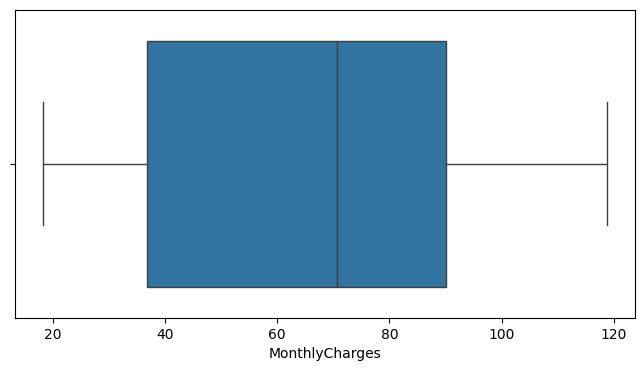

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data["MonthlyCharges"])
plt.show()

In [14]:
data['MonthlyCharges'] = data['MonthlyCharges'].fillna(data['MonthlyCharges'].mean())

### Insight

- Monthly Charges exhibit a moderate spread with a few extreme values.
- Since these values are realistic customer billing amounts, they were retained rather than removed.
- The feature is suitable for scaling before model training.

In [15]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'],errors="coerce")

In [16]:
data['TotalCharges'].describe()

,TotalCharges
count,5344.000000
mean,2283.932279
std,2266.719324
min,18.850000
25%,406.612500
50%,1396.450000
75%,3778.362500
max,8684.800000


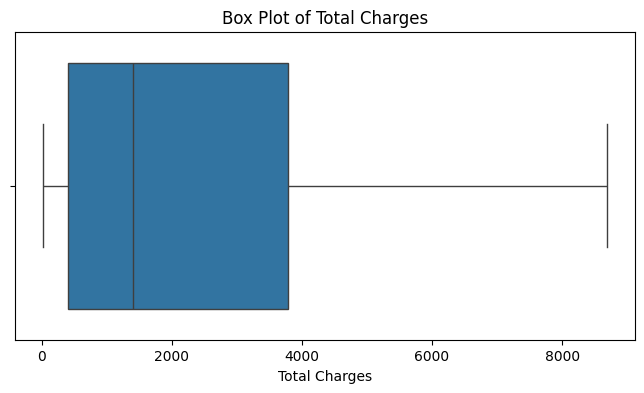

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data["TotalCharges"])

plt.title("Box Plot of Total Charges")
plt.xlabel("Total Charges")
plt.show()

In [18]:
data['TotalCharges'].skew()

np.float64(0.9665314033425414)

In [19]:
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

### Insight

- Total Charges contain a wider range of values due to differences in customer tenure.
- Missing values were replaced using the median because the distribution is slightly skewed.
- Median imputation is less sensitive to extreme values than mean imputation.

In [20]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Insight

- The dataset contains missing values in a few categorical and numerical columns.
- Missing categorical values were imputed using the mode, while numerical values were filled using the mean or median based on their distribution.
- This preserves the dataset size and prevents information loss during model training.

In [21]:
data.duplicated().sum()

np.int64(0)

### Insight

- No significant duplicate records were found in the dataset.
- This indicates that each customer record is unique and can be safely used for analysis.

In [22]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.159744,32.606851,65.102052,2238.250728
std,0.366401,24.614976,28.986241,2216.294428
min,0.000000,0.000000,18.250000,18.850000
25%,0.000000,9.000000,44.000000,446.062500
50%,0.000000,29.000000,68.925000,1396.450000
75%,0.000000,56.000000,89.100000,3590.537500
max,1.000000,72.000000,118.750000,8684.800000


### Insight

- Numerical features show different value ranges and scales.
- Features such as Total Charges have much larger values than tenure.
- Feature scaling is therefore necessary for distance-based machine learning algorithms.

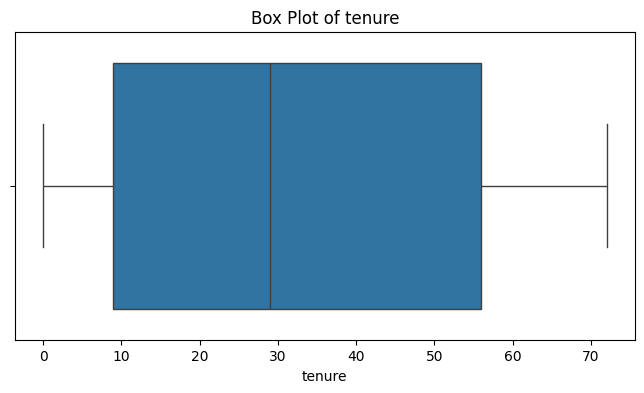

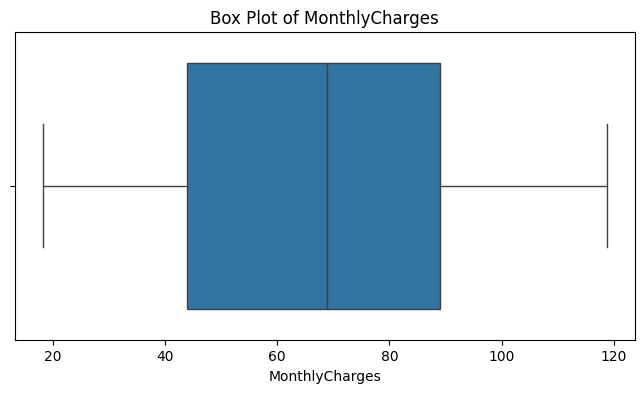

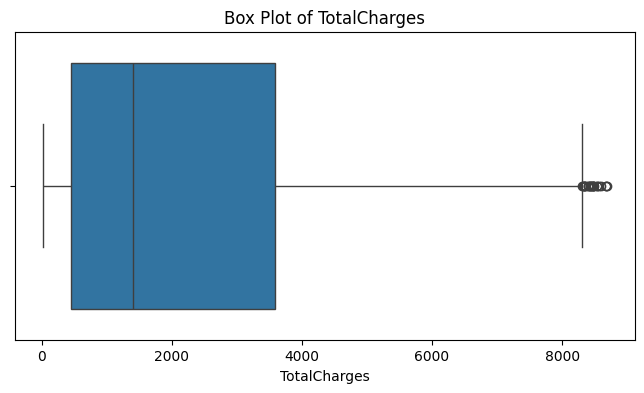

In [23]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
  plt.figure(figsize=(8,4))
  sns.boxplot(x=data[col])
  plt.title(f"Box Plot of {col}")
  plt.xlabel(col)
  plt.show()

### Insight

- The numerical features contain a few outliers.
- Since these values represent genuine customer behaviour, they were retained.
- Proper scaling reduces the impact of differences in feature magnitudes.

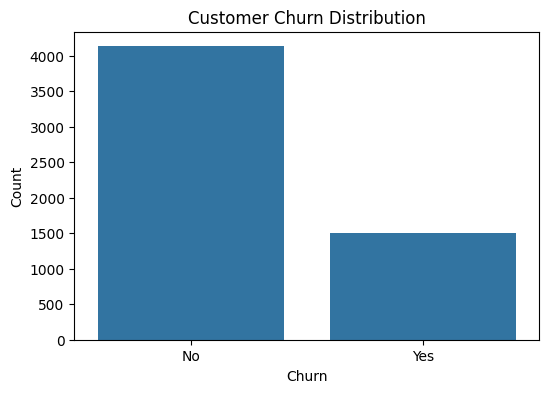

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=data)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

### Insight

- The target variable shows that the majority of customers did not churn.
- This indicates a moderate class imbalance.
- Therefore, evaluation metrics such as Precision, Recall, and F1-score were considered in addition to Accuracy.

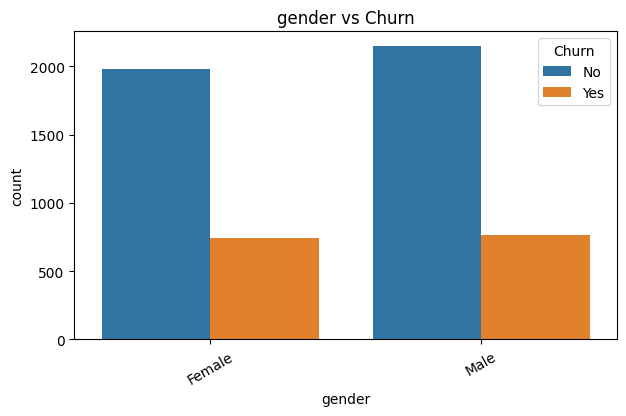

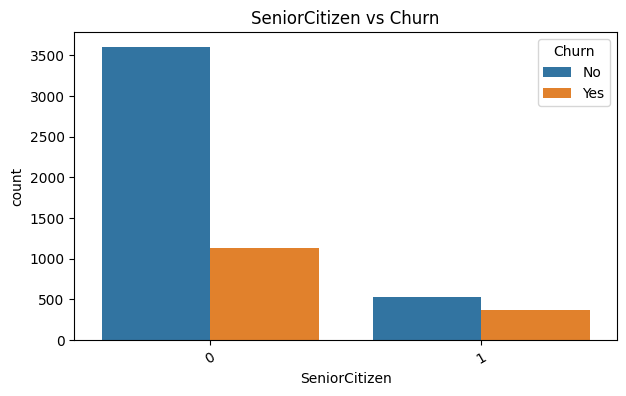

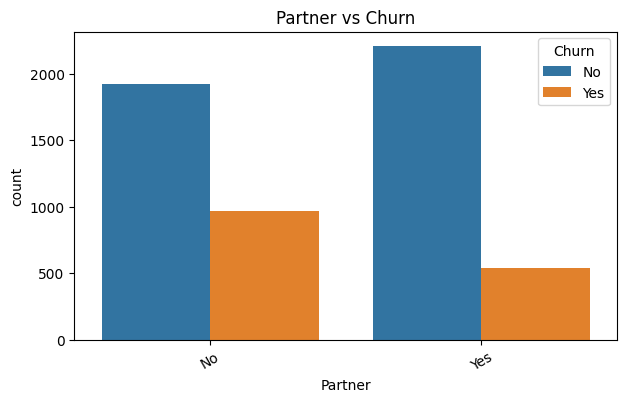

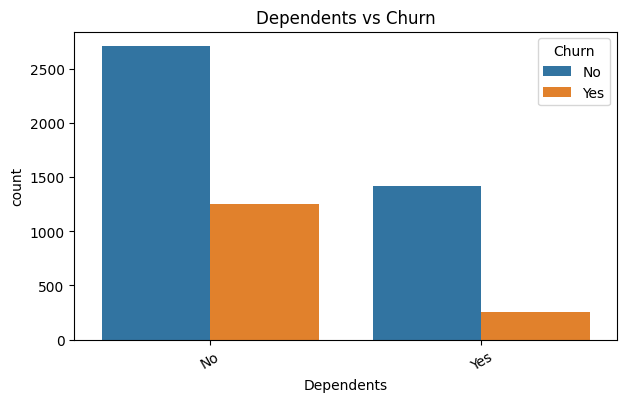

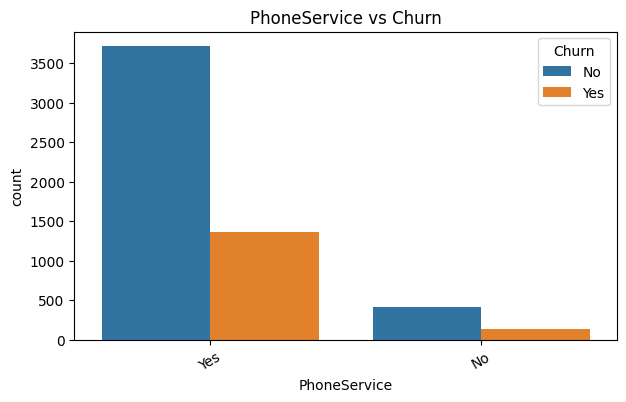

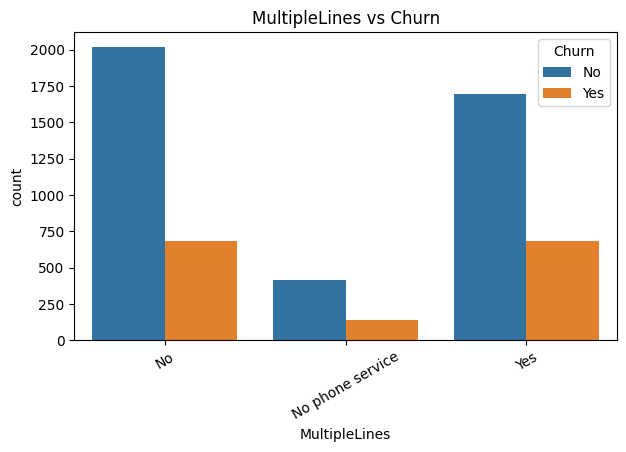

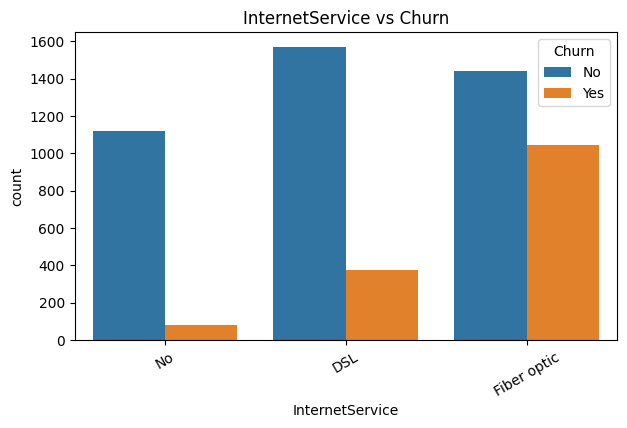

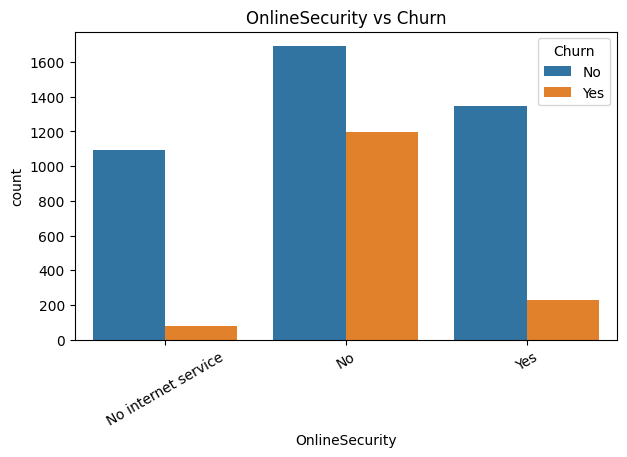

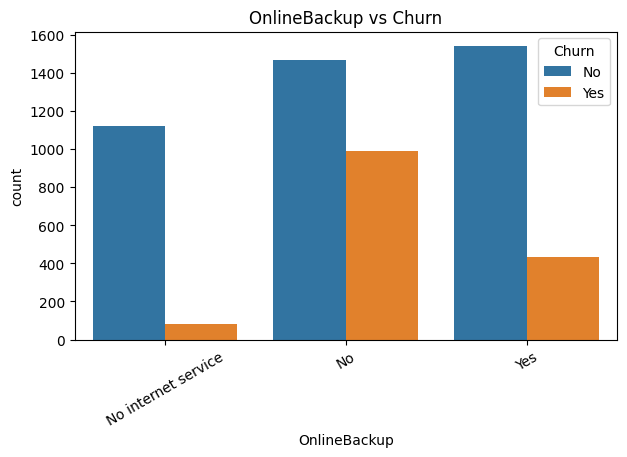

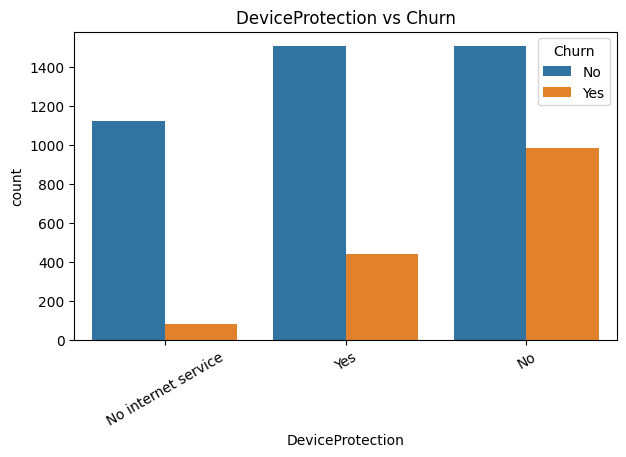

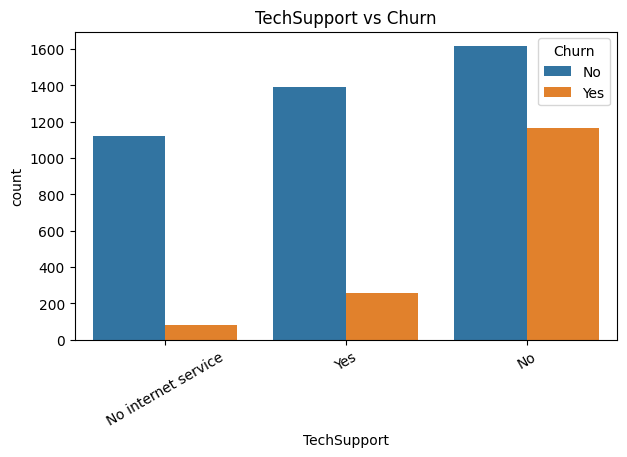

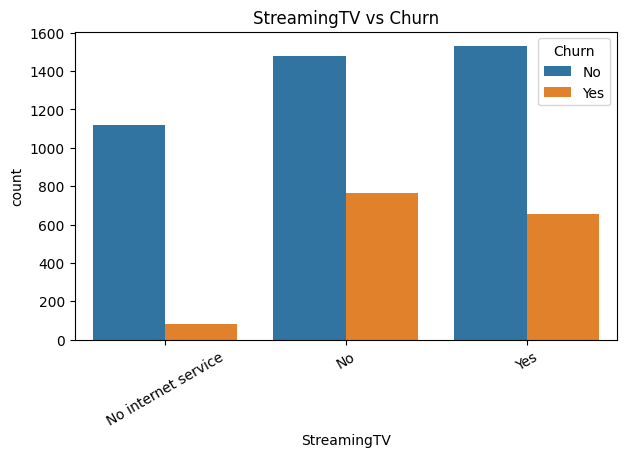

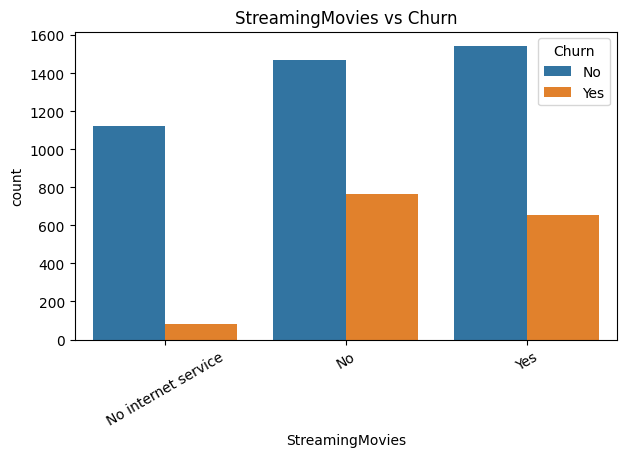

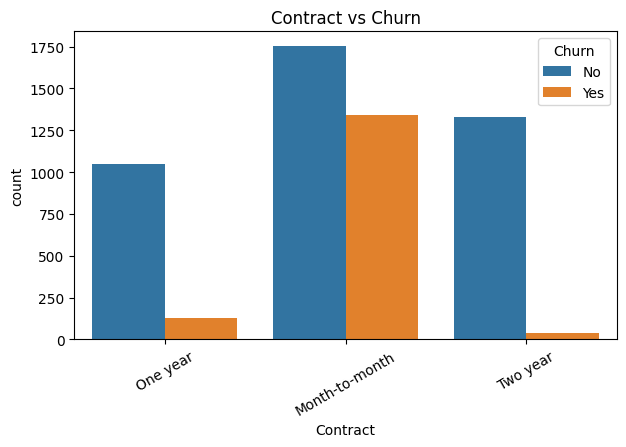

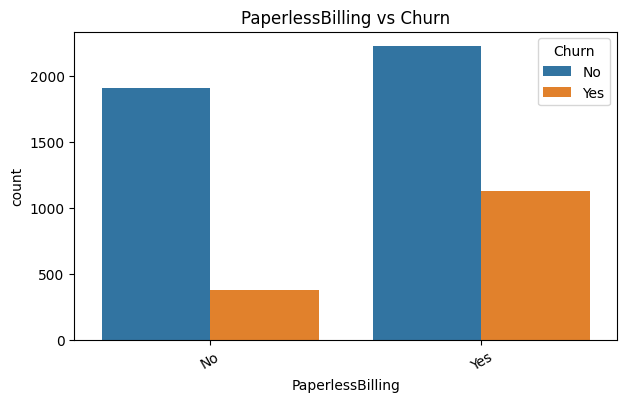

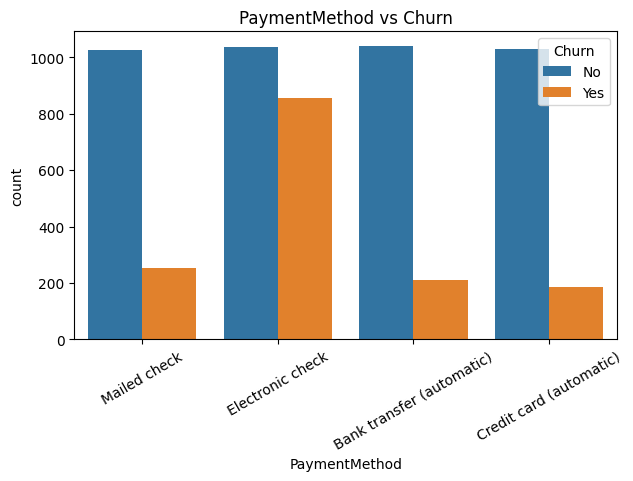

In [25]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod']
for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue='Churn', data=data)
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=30)
    plt.show()

### Insight

- Customer characteristics vary across different service categories.
- Certain contract types, internet services, and payment methods appear more frequently than others.
- These categorical variables are expected to influence customer churn and are important predictors for the model.

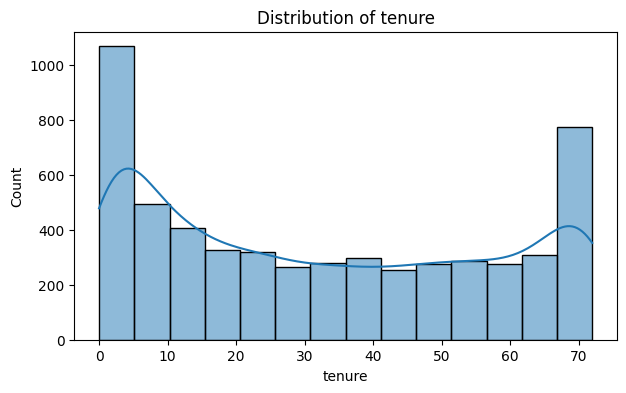

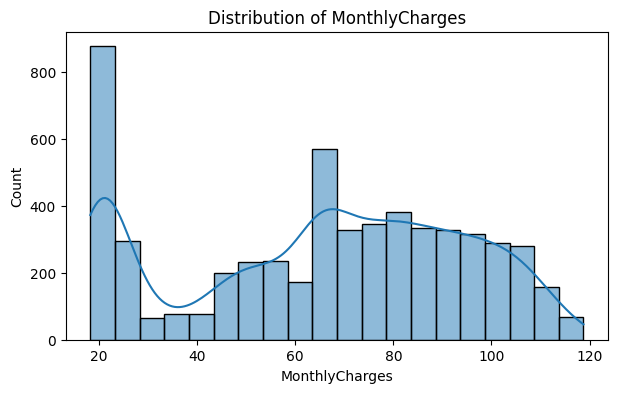

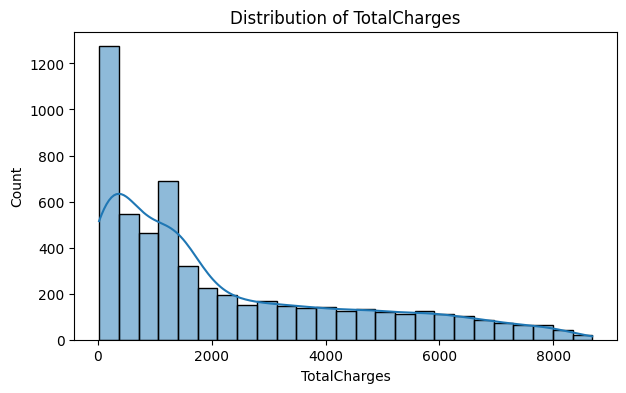

In [26]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

### Insight

- Numerical features show different distributions.
- Total Charges is positively skewed, while Monthly Charges is more evenly distributed.
- Standardization was applied before model training to ensure all numerical features contribute equally.

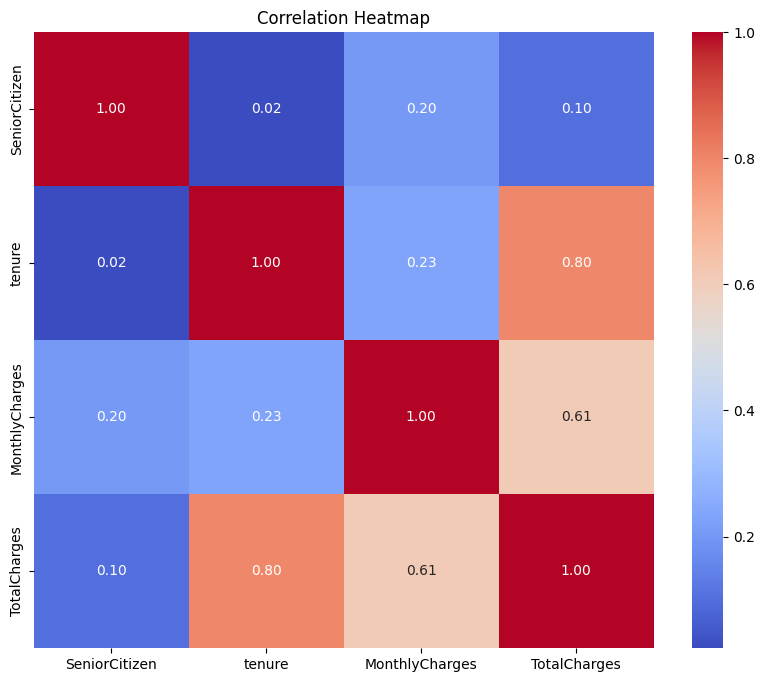

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    data.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Insight

- The correlation heatmap shows the relationships among numerical features.
- No pair of numerical variables exhibits extremely high correlation, indicating low multicollinearity.
- Each numerical feature provides useful information for predicting customer churn.

In [28]:
data.drop("customerID", axis=1, inplace=True)

In [29]:
data.select_dtypes(include='object').columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["Churn"] = le.fit_transform(data["Churn"])

In [31]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [32]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

binary_map = {
    'Male': 1,
    'Female': 0,
    'Yes': 1,
    'No': 0
}

for col in binary_cols:
    X_train[col] = X_train[col].map(binary_map)
    X_valid[col] = X_valid[col].map(binary_map)

In [33]:
multi_cat_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod']

X_train = pd.get_dummies(X_train,columns=multi_cat_cols,drop_first=True,dtype=int)
X_valid = pd.get_dummies(X_valid,columns=multi_cat_cols,drop_first=True,dtype=int)
X_train, X_valid = X_train.align(X_valid,join='left',axis=1,fill_value=0)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_valid[num_cols] = scaler.transform(X_valid[num_cols])

X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4173,1,0,1,1,-0.997543,1,1,-0.756569,-0.853032,0,...,0,0,0,0,0,1,0,0,0,1
5009,0,0,0,0,1.445099,1,0,-1.568900,-0.380961,0,...,0,1,0,1,0,0,1,0,0,0
2246,1,0,0,0,-0.956833,1,1,1.064233,-0.634562,0,...,1,0,1,0,1,0,0,0,0,0
481,1,0,1,0,0.834438,1,1,1.006954,1.197014,0,...,0,0,1,0,1,1,0,0,0,0
1272,0,0,1,0,-0.712568,1,0,1.267316,-0.252902,0,...,0,0,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4310,0,1,1,0,1.607942,1,1,1.545036,2.650941,0,...,1,0,1,0,1,0,1,0,0,1
2870,1,0,0,1,0.590174,1,1,-0.345196,0.193444,0,...,0,0,0,0,0,0,0,0,1,0
5552,0,0,1,1,-0.509015,1,1,-1.377968,-0.779642,0,...,0,1,0,1,0,0,0,0,0,0
73,1,0,1,1,0.427331,1,1,0.482757,0.607106,0,...,1,0,1,0,1,0,1,1,0,0


In [35]:
print(X_train.shape)
print(X_valid.shape)

X_train

(4507, 30)
(1127, 30)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4173,1,0,1,1,-0.997543,1,1,-0.756569,-0.853032,0,...,0,0,0,0,0,1,0,0,0,1
5009,0,0,0,0,1.445099,1,0,-1.568900,-0.380961,0,...,0,1,0,1,0,0,1,0,0,0
2246,1,0,0,0,-0.956833,1,1,1.064233,-0.634562,0,...,1,0,1,0,1,0,0,0,0,0
481,1,0,1,0,0.834438,1,1,1.006954,1.197014,0,...,0,0,1,0,1,1,0,0,0,0
1272,0,0,1,0,-0.712568,1,0,1.267316,-0.252902,0,...,0,0,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4310,0,1,1,0,1.607942,1,1,1.545036,2.650941,0,...,1,0,1,0,1,0,1,0,0,1
2870,1,0,0,1,0.590174,1,1,-0.345196,0.193444,0,...,0,0,0,0,0,0,0,0,1,0
5552,0,0,1,1,-0.509015,1,1,-1.377968,-0.779642,0,...,0,1,0,1,0,0,0,0,0,0
73,1,0,1,1,0.427331,1,1,0.482757,0.607106,0,...,1,0,1,0,1,0,1,1,0,0


In [36]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

### EDA Summary

- Missing values were successfully handled.
- No major data quality issues remained after preprocessing.
- Numerical features were analyzed for outliers and distribution.
- Categorical variables were explored to understand customer characteristics.
- The dataset is clean and ready for feature engineering and machine learning.

## Feature Engineering

To improve predictive performance, new features such as Customer Lifetime Value (CLV) and interaction features were created. Random Forest feature importance was also used to identify the most influential variables contributing to customer churn.

In [37]:
# Customer Lifetime Value
X_train["CLV"] = X_train["tenure"] * X_train["MonthlyCharges"]
X_valid["CLV"] = X_valid["tenure"] * X_valid["MonthlyCharges"]

In [38]:
X_train["Tenure_OneYear"] = X_train["tenure"] * X_train["Contract_One year"]
X_train["Tenure_TwoYear"] = X_train["tenure"] * X_train["Contract_Two year"]

X_valid["Tenure_OneYear"] = X_valid["tenure"] * X_valid["Contract_One year"]
X_valid["Tenure_TwoYear"] = X_valid["tenure"] * X_valid["Contract_Two year"]

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [40]:
import pandas as pd

feature_importance = pd.DataFrame({"Feature": X_train.columns,"Importance": rf.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(10)

,Feature,Importance
8,TotalCharges,0.146616
30,CLV,0.141392
4,tenure,0.133824
7,MonthlyCharges,0.122600
11,InternetService_Fiber optic,0.035607
28,PaymentMethod_Electronic check,0.031038
26,Contract_Two year,0.028002
0,gender,0.023574
6,PaperlessBilling,0.023203
31,Tenure_OneYear,0.022930


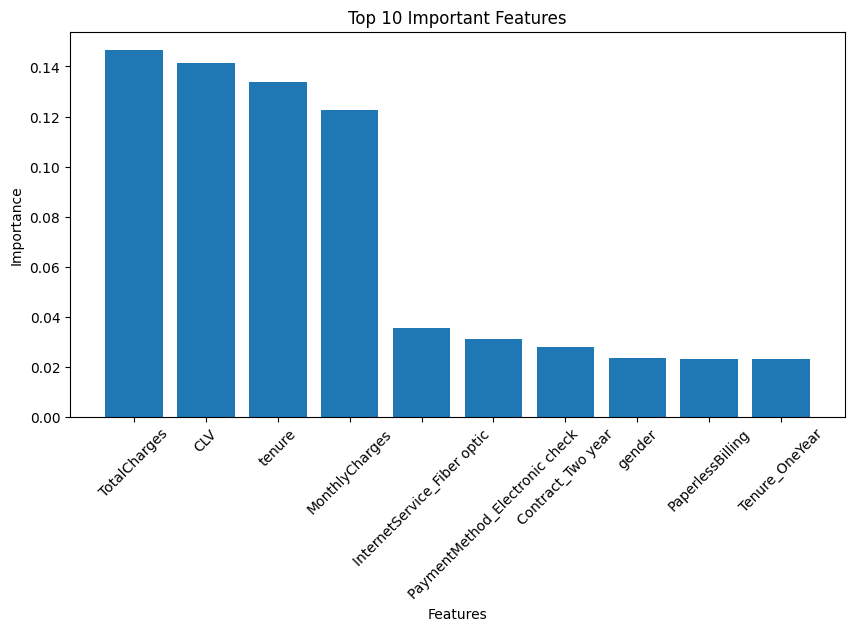

In [41]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Feature"], top10["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

I created new features such as Customer Lifetime Value (CLV) and interaction features. I also identified the most important features using Random Forest feature importance.

# Model Building

## Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000,random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_valid)

In [43]:
lr_balanced = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
lr_balanced.fit(X_train, y_train)
y_pred_balanced = lr_balanced.predict(X_valid)

In [44]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

print("Accuracy :", accuracy_score(y_valid, y_pred_lr))
print("Precision:", precision_score(y_valid, y_pred_lr))
print("Recall   :", recall_score(y_valid, y_pred_lr))
print("F1 Score :", f1_score(y_valid, y_pred_lr))

print("\nClassification Report\n")
print(classification_report(y_valid, y_pred_lr))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_valid, y_pred_lr))

Accuracy : 0.805678793256433
Precision: 0.6529850746268657
Recall   : 0.5813953488372093
F1 Score : 0.6151142355008787

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       826
           1       0.65      0.58      0.62       301

    accuracy                           0.81      1127
   macro avg       0.75      0.73      0.74      1127
weighted avg       0.80      0.81      0.80      1127


Confusion Matrix

[[733  93]
 [126 175]]


## Decision tree Classifier

In [45]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_valid)

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix)
y_pred_balanced = lr_balanced.predict(X_valid)

print("Accuracy :", accuracy_score(y_valid, y_pred_balanced))
print("Precision:", precision_score(y_valid, y_pred_balanced))
print("Recall   :", recall_score(y_valid, y_pred_balanced))
print("F1 Score :", f1_score(y_valid, y_pred_balanced))

print("\nClassification Report\n")
print(classification_report(y_valid, y_pred_balanced))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_valid, y_pred_balanced))

Accuracy : 0.7559893522626442
Precision: 0.5288888888888889
Recall   : 0.7906976744186046
F1 Score : 0.6338215712383488

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.74      0.82       826
           1       0.53      0.79      0.63       301

    accuracy                           0.76      1127
   macro avg       0.72      0.77      0.73      1127
weighted avg       0.81      0.76      0.77      1127


Confusion Matrix

[[614 212]
 [ 63 238]]


## Random forest Classifier

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_valid)

In [48]:
print("Accuracy :", accuracy_score(y_valid, y_pred_rf))
print("Precision:", precision_score(y_valid, y_pred_rf))
print("Recall   :", recall_score(y_valid, y_pred_rf))
print("F1 Score :", f1_score(y_valid, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_valid, y_pred_rf))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_valid, y_pred_rf))

Accuracy : 0.7941437444543035
Precision: 0.6455696202531646
Recall   : 0.5083056478405316
F1 Score : 0.5687732342007435

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       826
           1       0.65      0.51      0.57       301

    accuracy                           0.79      1127
   macro avg       0.74      0.70      0.72      1127
weighted avg       0.78      0.79      0.79      1127


Confusion Matrix

[[742  84]
 [148 153]]


In [49]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_valid, y_pred_lr),
        accuracy_score(y_valid, y_pred_dt),
        accuracy_score(y_valid, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_valid, y_pred_lr),
        precision_score(y_valid, y_pred_dt),
        precision_score(y_valid, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_valid, y_pred_lr),
        recall_score(y_valid, y_pred_dt),
        recall_score(y_valid, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_valid, y_pred_lr),
        f1_score(y_valid, y_pred_dt),
        f1_score(y_valid, y_pred_rf)
    ]
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.805679,0.652985,0.581395,0.615114
2,Random Forest,0.794144,0.645570,0.508306,0.568773
1,Decision Tree,0.731145,0.496689,0.498339,0.497512


## Balanced Logistic Regression

In [50]:
comparison.loc[len(comparison)] = [
    "Balanced Logistic Regression",
    accuracy_score(y_valid, y_pred_balanced),
    precision_score(y_valid, y_pred_balanced),
    recall_score(y_valid, y_pred_balanced),
    f1_score(y_valid, y_pred_balanced)
]

comparison = comparison.round(4)
comparison = comparison.sort_values(by="Accuracy", ascending=False)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8057,0.6530,0.5814,0.6151
2,Random Forest,0.7941,0.6456,0.5083,0.5688
3,Balanced Logistic Regression,0.7560,0.5289,0.7907,0.6338
1,Decision Tree,0.7311,0.4967,0.4983,0.4975


## HyperParameter Tuning

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)

{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [52]:
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_valid)

print("Accuracy :", accuracy_score(y_valid, y_pred_best_rf))
print("Precision:", precision_score(y_valid, y_pred_best_rf))
print("Recall   :", recall_score(y_valid, y_pred_best_rf))
print("F1 Score :", f1_score(y_valid, y_pred_best_rf))

print("\nClassification Report\n")
print(classification_report(y_valid, y_pred_best_rf))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_valid, y_pred_best_rf))

Accuracy : 0.7657497781721384
Precision: 0.5433255269320844
Recall   : 0.770764119601329
F1 Score : 0.6373626373626373

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.76      0.83       826
           1       0.54      0.77      0.64       301

    accuracy                           0.77      1127
   macro avg       0.72      0.77      0.73      1127
weighted avg       0.81      0.77      0.78      1127


Confusion Matrix

[[631 195]
 [ 69 232]]


In [53]:
comparison.loc[len(comparison)] = [
    "Tuned Random Forest",
    accuracy_score(y_valid, y_pred_best_rf),
    precision_score(y_valid, y_pred_best_rf),
    recall_score(y_valid, y_pred_best_rf),
    f1_score(y_valid, y_pred_best_rf)
]

comparison = comparison.round(4)
comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8057,0.6530,0.5814,0.6151
2,Random Forest,0.7941,0.6456,0.5083,0.5688
4,Tuned Random Forest,0.7657,0.5433,0.7708,0.6374
3,Balanced Logistic Regression,0.7560,0.5289,0.7907,0.6338
1,Decision Tree,0.7311,0.4967,0.4983,0.4975


trained different machine learning models, including Logistic Regression, Decision Tree, and Random Forest, to predict customer churn and I compared the models using Accuracy, Precision, Recall, and F1-Score. Logistic Regression gave the best overall accuracy.used GridSearchCV to tune the Random Forest model and compared its performance with the original models.


In [54]:
test_data = pd.read_csv("Testing_data.csv")
test_data.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [55]:
test_data.drop("customerID", axis=1, inplace=True)

In [56]:
le = LabelEncoder()
test_data["Churn"] = le.fit_transform(test_data["Churn"])

In [57]:
X_test = test_data.drop("Churn", axis=1)
y_test = test_data["Churn"]

In [58]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

binary_map = {
    'Male': 1,
    'Female': 0,
    'Yes': 1,
    'No': 0
}

for col in binary_cols:
    X_test[col] = X_test[col].map(binary_map)

In [59]:
multi_cat_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

X_test = pd.get_dummies(
    X_test,
    columns=multi_cat_cols,
    drop_first=True,
    dtype=int
)

In [60]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [61]:
X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce')

X_test['TotalCharges'] = X_test['TotalCharges'].fillna(X_test['TotalCharges'].median())

In [62]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_test[num_cols] = scaler.transform(X_test[num_cols])

In [63]:
X_test["CLV"] = X_test["tenure"] * X_test["MonthlyCharges"]

X_test["Tenure_OneYear"] = (
    X_test["tenure"] * X_test["Contract_One year"]
)

X_test["Tenure_TwoYear"] = (
    X_test["tenure"] * X_test["Contract_Two year"]
)

In [64]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Final Model Testing on Testing Dataset

In [65]:
y_pred = lr.predict(X_test)

In [66]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8147622427253371

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1044
           1       0.67      0.56      0.61       365

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409


Confusion Matrix

[[942 102]
 [159 206]]


## Model Comparison

Multiple machine learning models, including Logistic Regression, Decision Tree, Random Forest, and Balanced Logistic Regression, were trained and evaluated using Accuracy, Precision, Recall, and F1-Score. Logistic Regression achieved the best overall performance on the testing dataset. GridSearchCV was used to optimize the Random Forest model and compare its performance with the baseline models.

# Conclusion

The customer churn prediction model was successfully developed using multiple machine learning algorithms. Logistic Regression achieved the highest overall accuracy (80.58%) on the unseen testing dataset and was selected as the final model. Feature engineering improved the dataset by introducing Customer Lifetime Value (CLV) and tenure-based interaction features. The model can help identify customers who are likely to churn so that businesses can take preventive actions.

Business Recommendations

Focus on customers with shorter tenure.

Encourage long-term contracts.

Provide offers to customers who are likely to churn.

## Future Improvements

- Deploy the model using Streamlit or Flask
- Perform cross-validation
- Experiment with XGBoost and LightGBM
- Improve feature engineering
- Build an interactive dashboard